# CPC et CMIIC dans agrum2 vs agrum3

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
from pathlib import Path

# Use LaTeX-like font (Computer Modern) — same as latex_report_plots.ipynb
matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

In [2]:
# Donnees : les CSV unifies du remetrics (metriques recalculees par le meme code).
# CPC/CMIIC y figurent en deux versions : agrum2 = clean_rerun, agrum3 = run natif.
ALGOS = ["CPC", "CMIIC"]

def load_pair(gen):
    """CPC/CMIIC des deux versions d'agrum, depuis le CSV du remetrics."""
    df = pd.read_csv(f"{gen}.csv")
    return df[df.algo.isin(ALGOS)]

In [3]:
# Same layout as the report's benchmark results section, per (generator, n_vars):
#   row 1: time + legend    row 2: SHD/F1/TPR on CPDAGs    row 3: same on skeletons
# 4 curves: color = algo, linestyle = version (solid agrum3, dashed agrum2)
from matplotlib.lines import Line2D

PALETTE = {"CPC": "tab:blue", "CMIIC": "tab:orange"}
DASHES  = {"agrum3": "", "agrum2": (4, 2)}

LEGEND_HANDLES = [
    Line2D([], [], color=PALETTE["CPC"],   ls="-",  marker="o", label="CPC (agrum3)"),
    Line2D([], [], color=PALETTE["CPC"],   ls="--", marker="o", label="CPC (agrum2)"),
    Line2D([], [], color=PALETTE["CMIIC"], ls="-",  marker="o", label="CMIIC (agrum3)"),
    Line2D([], [], color=PALETTE["CMIIC"], ls="--", marker="o", label="CMIIC (agrum2)"),
]

CPDAG_METRICS = [("SHD", "SHD (on CPDAGs)"),
                 ("F1-Score", "F1 (on CPDAGs)"),
                 ("TPR", "TPR (on CPDAGs)")]
SKELETON_METRICS = [("SHD_skeleton", "SHD (on skeletons)"),
                    ("F1-Score_skeleton", "F1 (on skeletons)"),
                    ("TPR_skeleton", "TPR (on skeletons)")]

SAVE = False  # True -> save PNGs in figures_compare/<generator>/

def _draw(ax, data, y, ylabel):
    sns.lineplot(
        data=data, x="n_samples", y=y,
        hue="algo", hue_order=ALGOS, palette=PALETTE,
        style="version", style_order=["agrum3", "agrum2"], dashes=DASHES,
        errorbar="se", marker="o", ax=ax, legend=False,
    )
    ax.set_xlabel("Number of samples")
    ax.set_ylabel(ylabel)

def _save(fig, gen, name):
    if SAVE:
        save_dir = Path(f"figures_compare/{gen}")
        save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / name, dpi=300, bbox_inches="tight")

def plot_generator(gen):
    df = load_pair(gen)
    for n_vars in (10, 20):
        data = df[df.n_vars == n_vars]

        # row 1: time + legend
        fig, axes = plt.subplots(1, 2, figsize=(10, 3.5),
                                 gridspec_kw={"width_ratios": [1, 0.5]})
        _draw(axes[0], data, "time_s", "Time (seconds)")
        axes[1].axis("off")
        axes[1].legend(handles=LEGEND_HANDLES, loc="center", frameon=True, fontsize=12)
        fig.suptitle(f"{gen} — {n_vars} variables", y=1.02)
        fig.tight_layout()
        _save(fig, gen, f"{gen}_{n_vars}v_time.png")
        plt.show()

        # rows 2-3: CPDAGs then skeletons
        for metrics, tag in [(CPDAG_METRICS, "cpdags"), (SKELETON_METRICS, "skeletons")]:
            fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
            for ax, (y, ylabel) in zip(axes, metrics):
                _draw(ax, data, y, ylabel)
            fig.tight_layout()
            _save(fig, gen, f"{gen}_{n_vars}v_{tag}.png")
            plt.show()

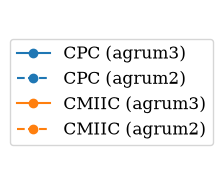

In [4]:
# Standalone legend figure (report's scaling_legend.png) — only useful with SAVE=True
fig, ax = plt.subplots(figsize=(2, 2))
ax.axis("off")
fig.legend(handles=LEGEND_HANDLES, loc="center", ncol=1, frameon=True, fontsize=12)
fig.tight_layout()
if SAVE:
    Path("figures_compare").mkdir(exist_ok=True)
    fig.savefig("figures_compare/scaling_legend.png", dpi=600, bbox_inches="tight")
plt.show()

## sem_gaussian

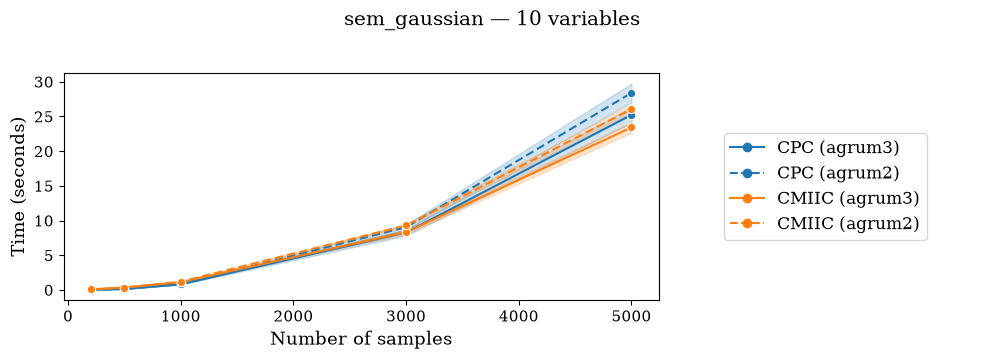

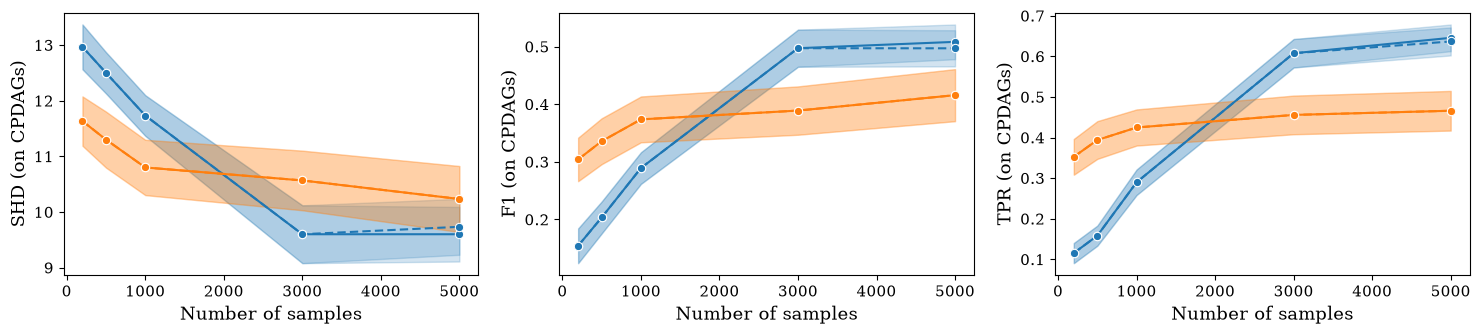

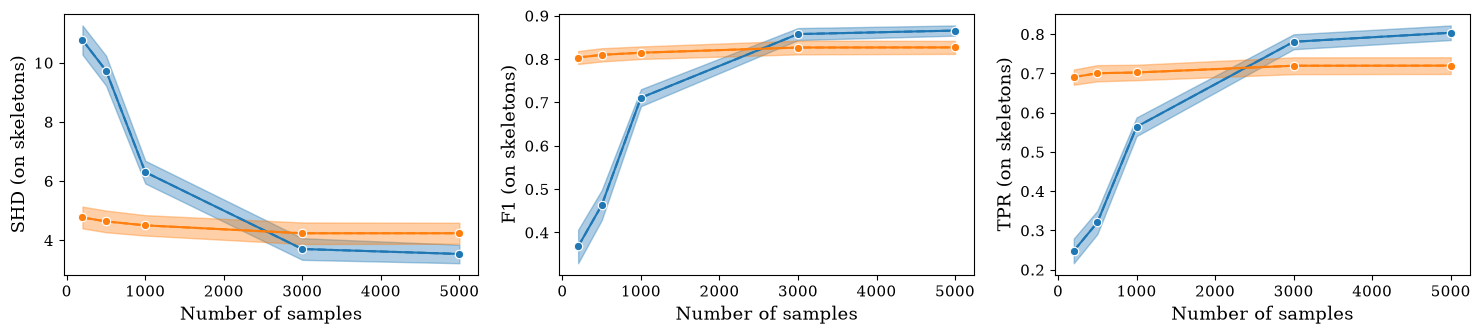

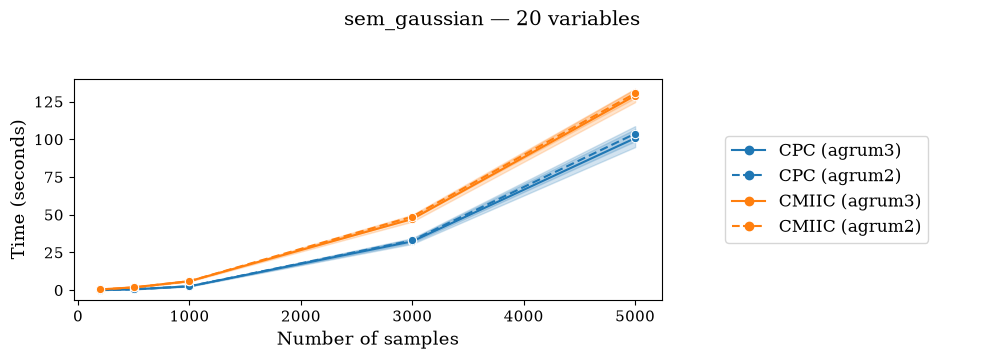

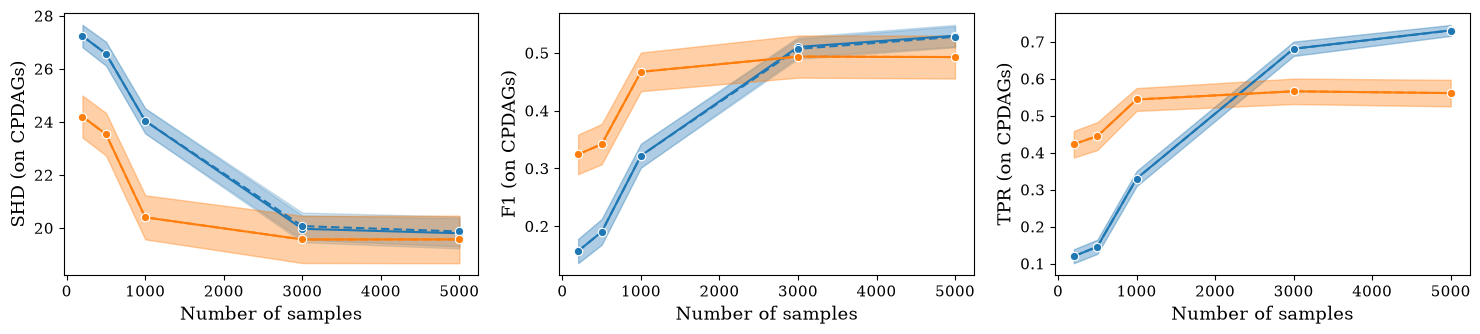

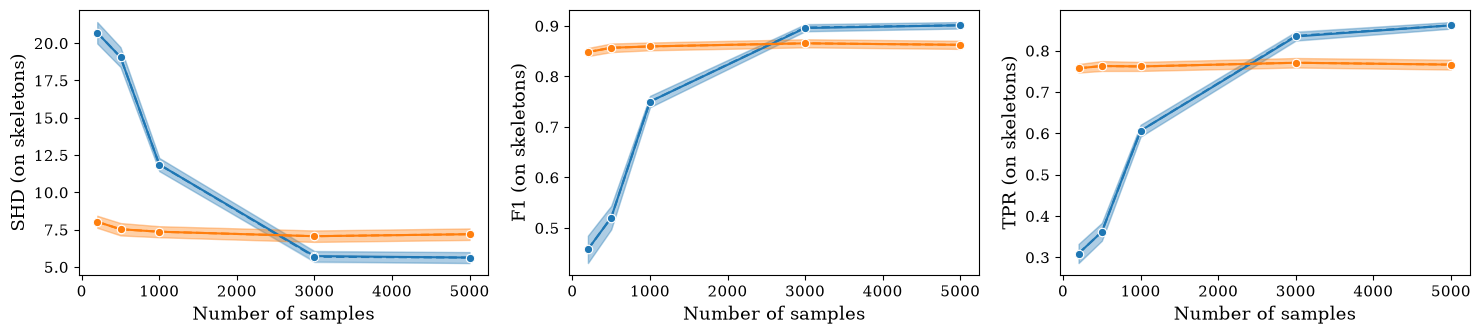

In [5]:
plot_generator("sem_gaussian")

## sem_laplace

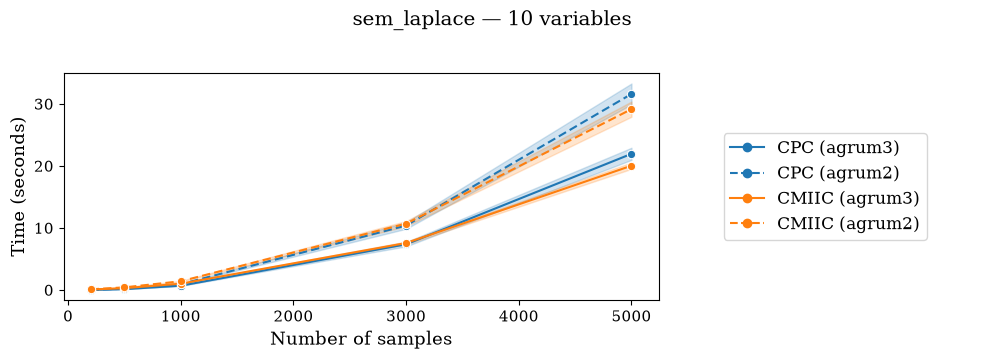

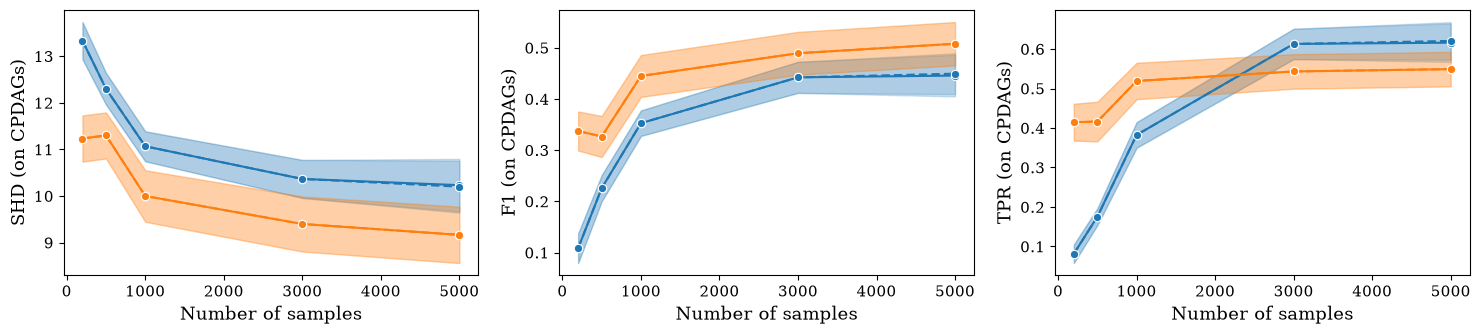

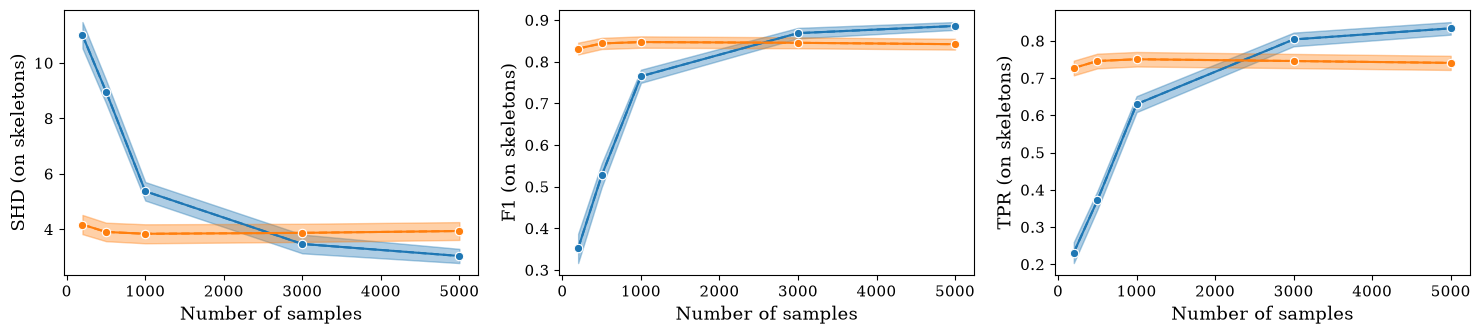

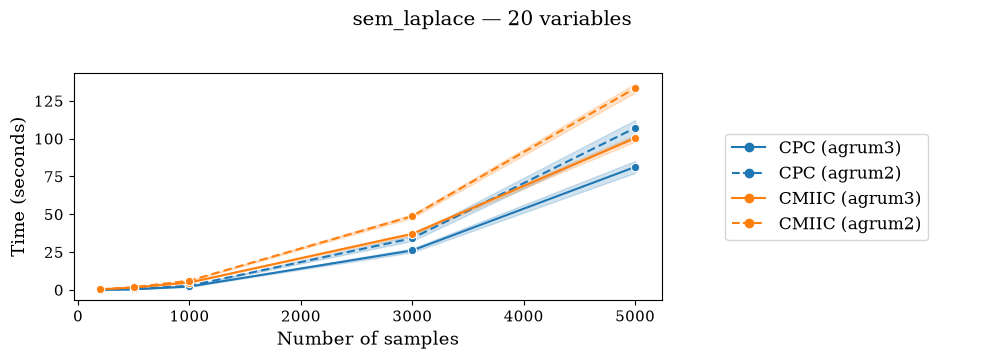

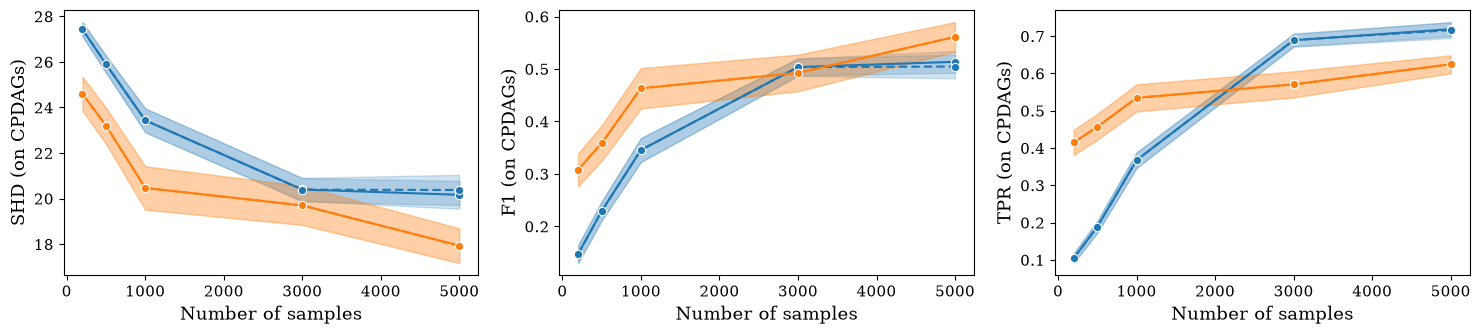

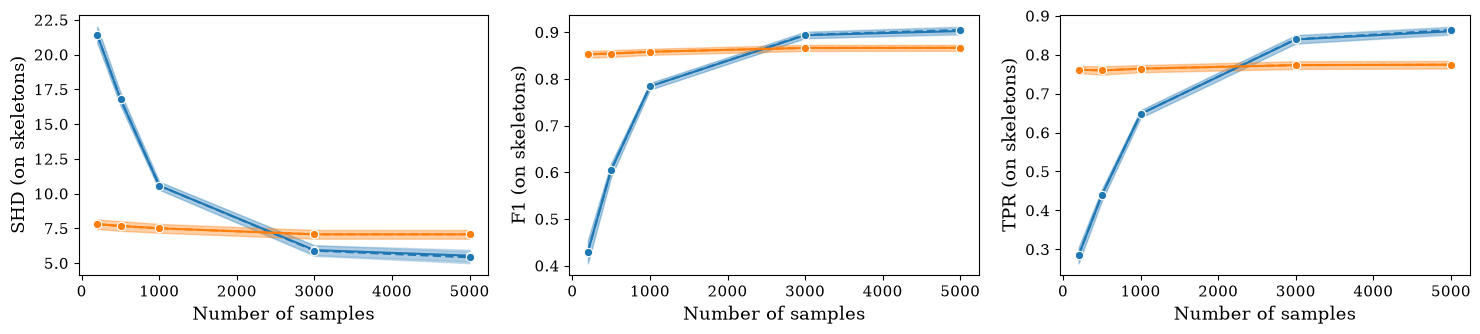

In [6]:
plot_generator("sem_laplace")

## cbn_unif_gauss

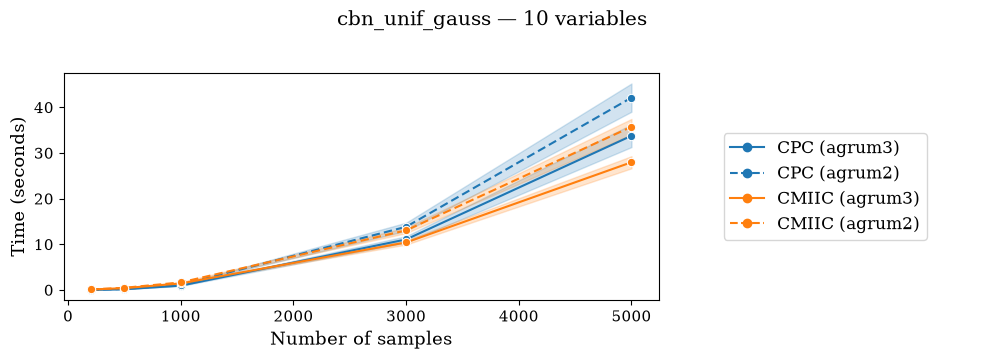

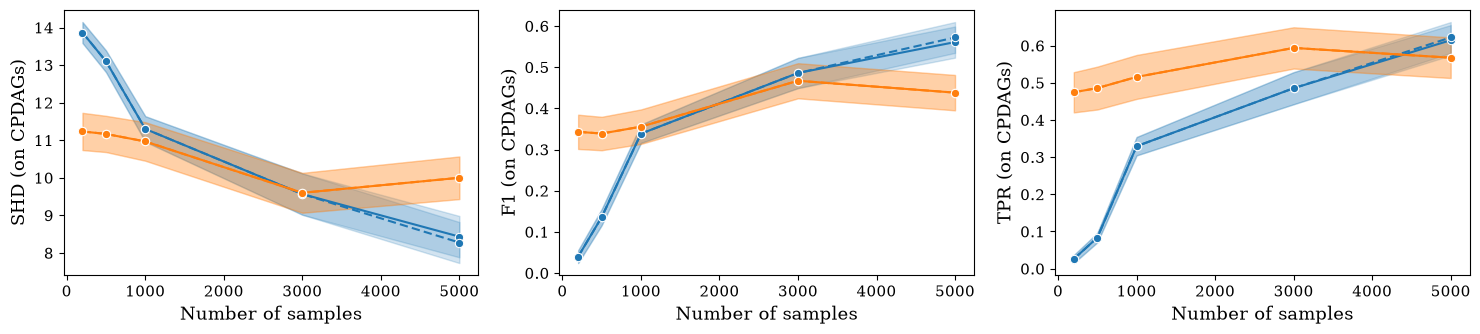

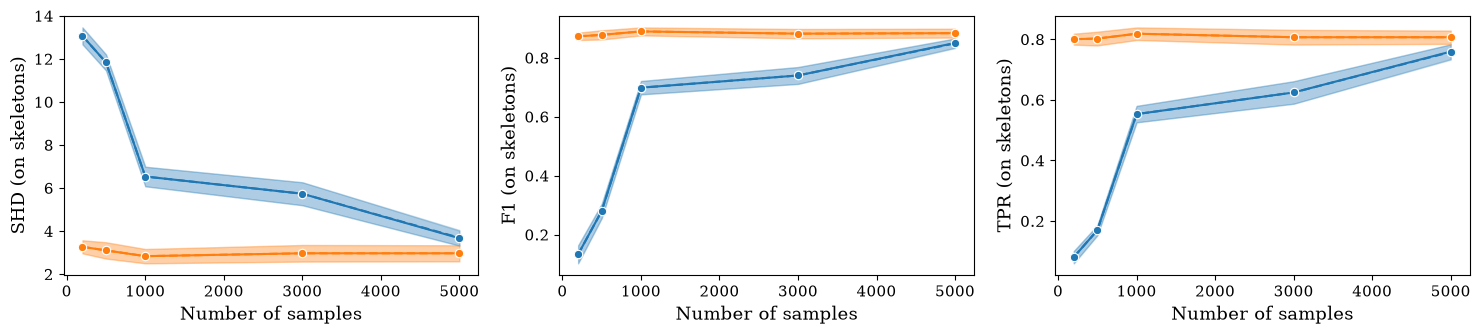

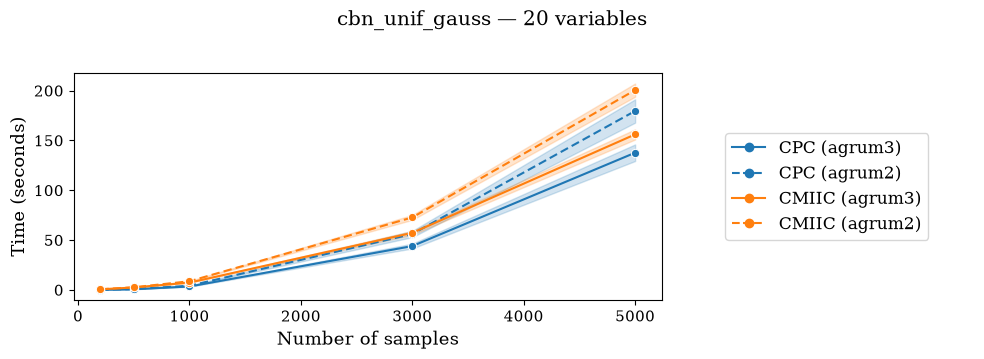

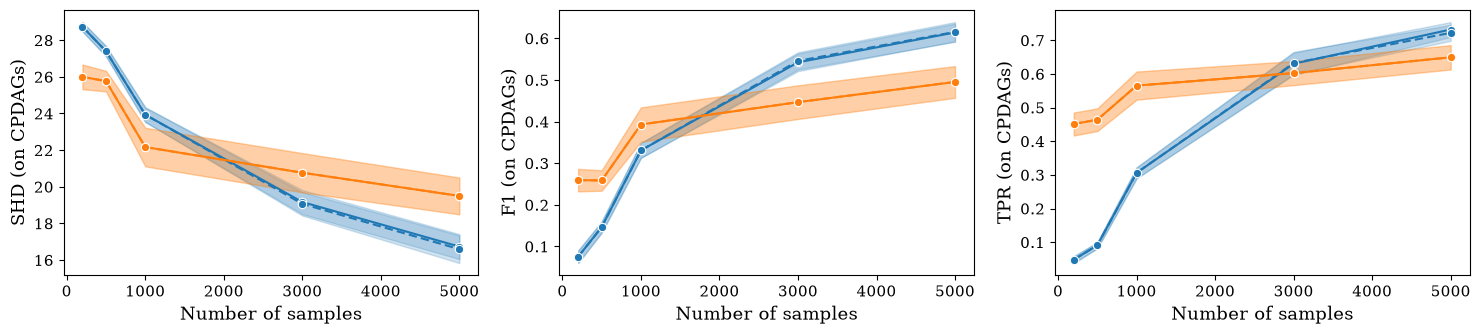

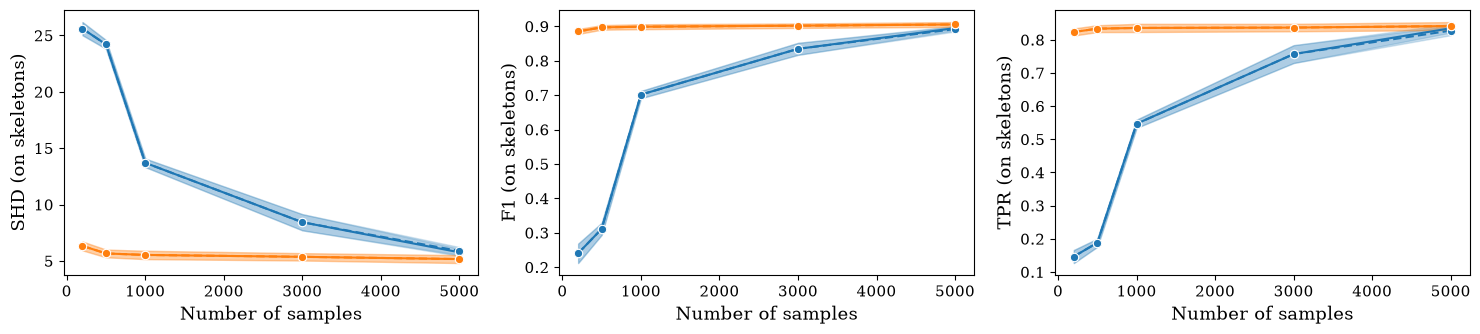

In [7]:
plot_generator("cbn_unif_gauss")

## cbn_exp_clayton

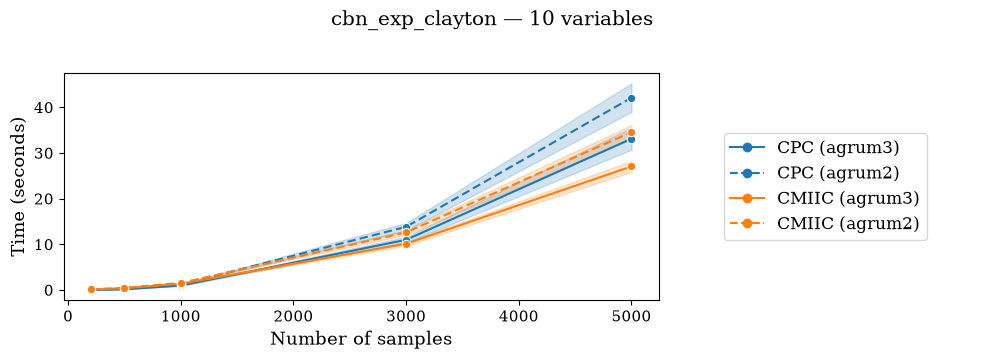

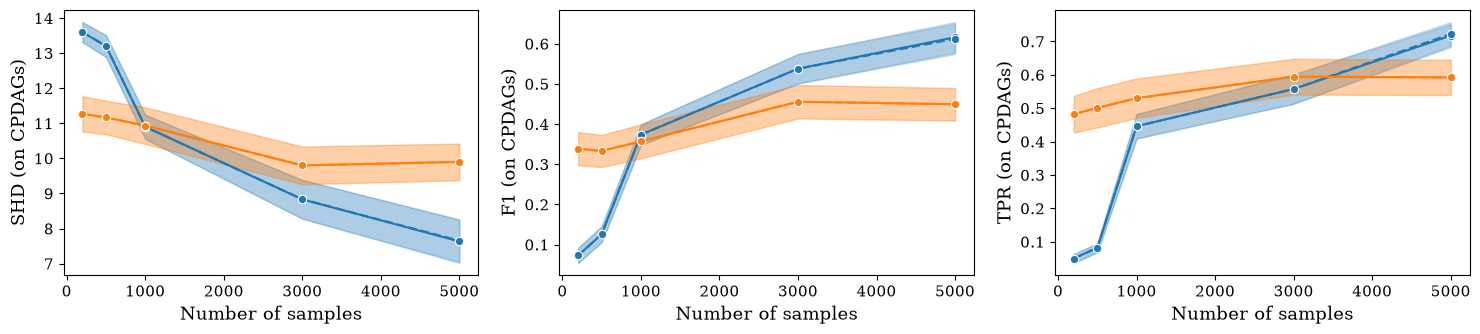

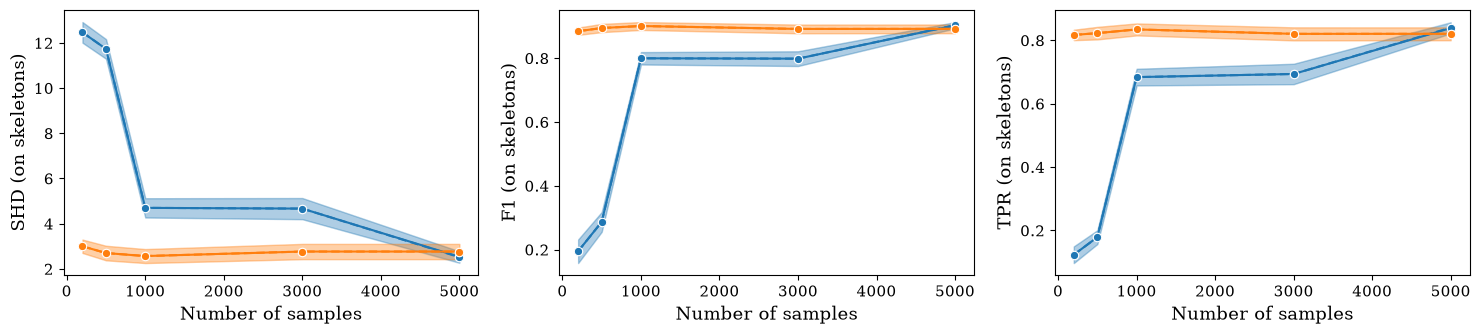

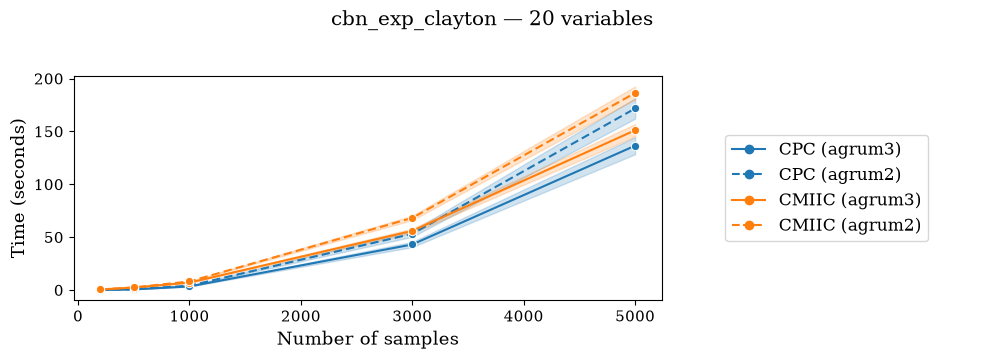

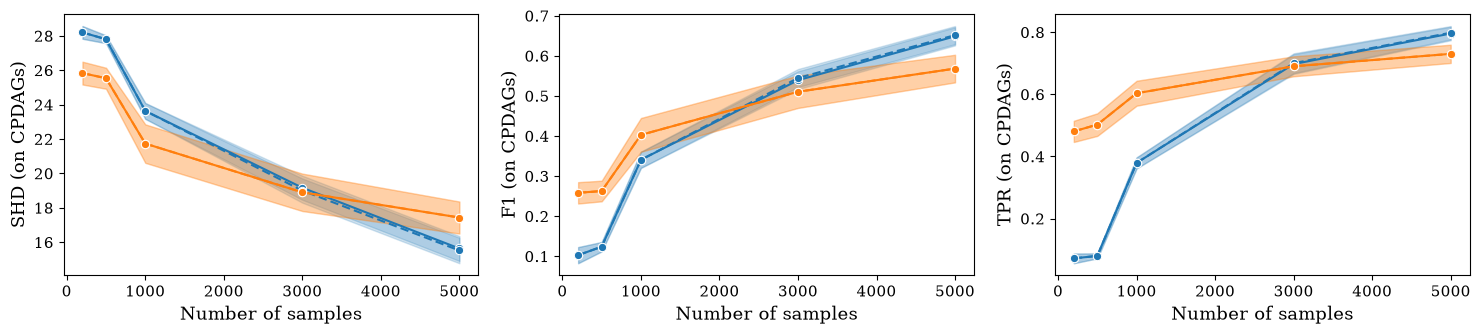

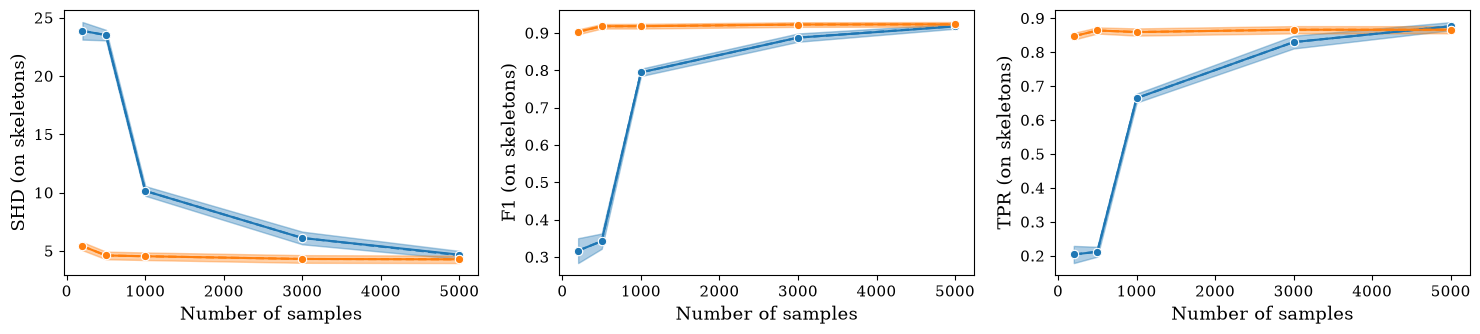

In [8]:
plot_generator("cbn_exp_clayton")

## cbn_unif_mixture

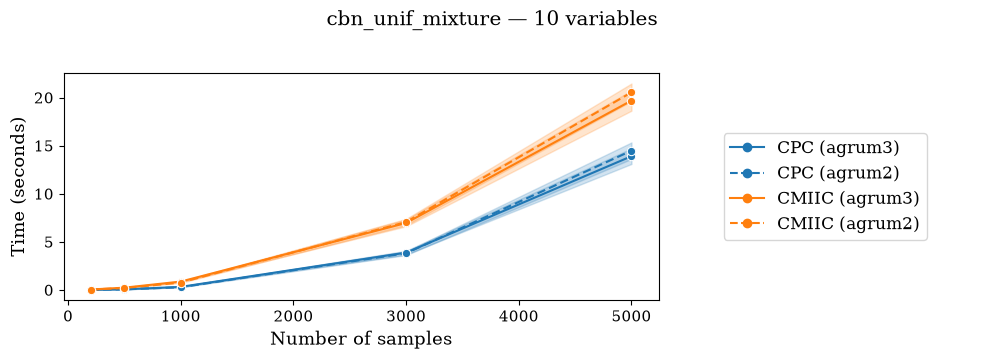

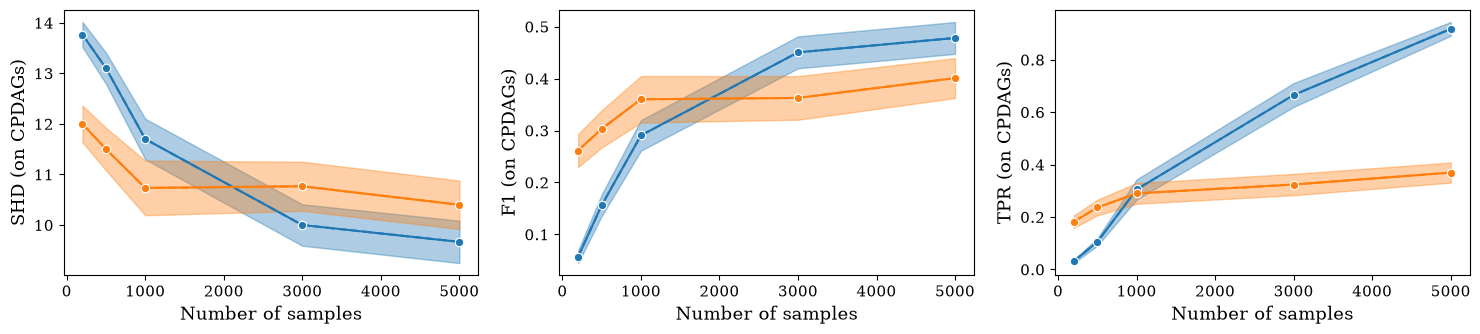

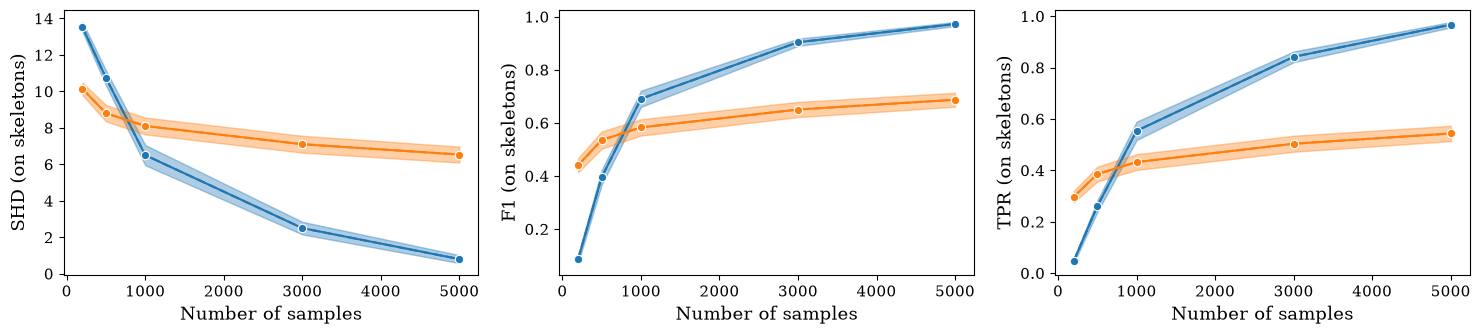

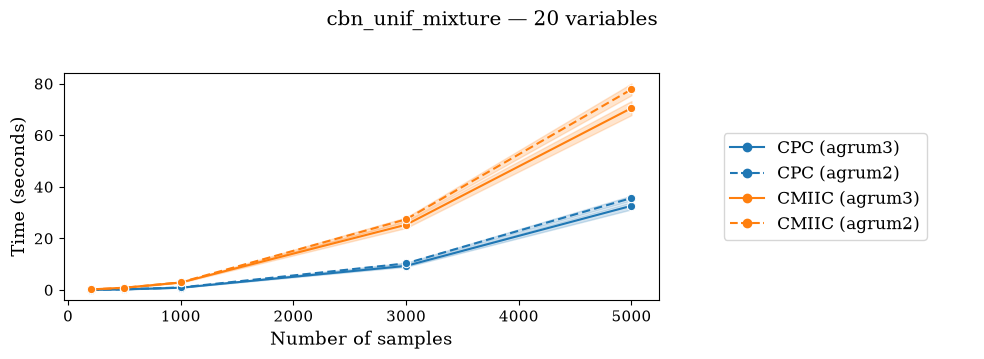

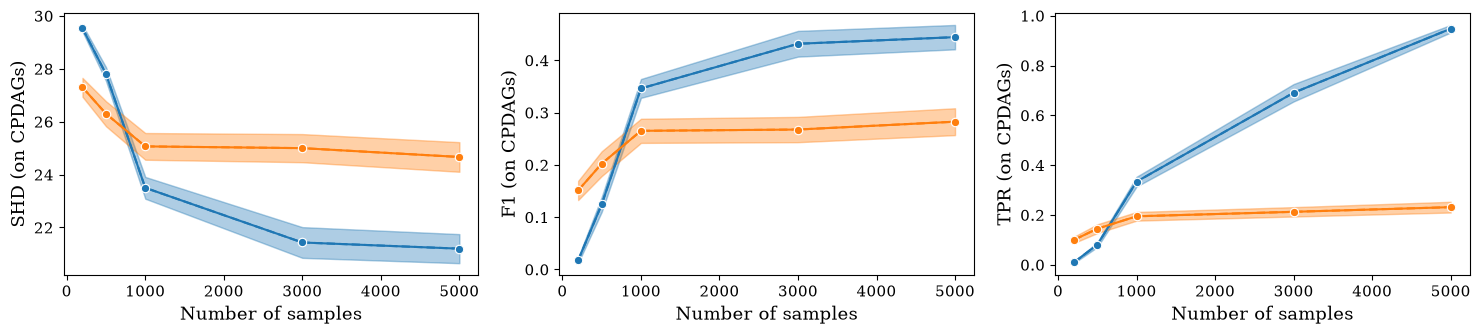

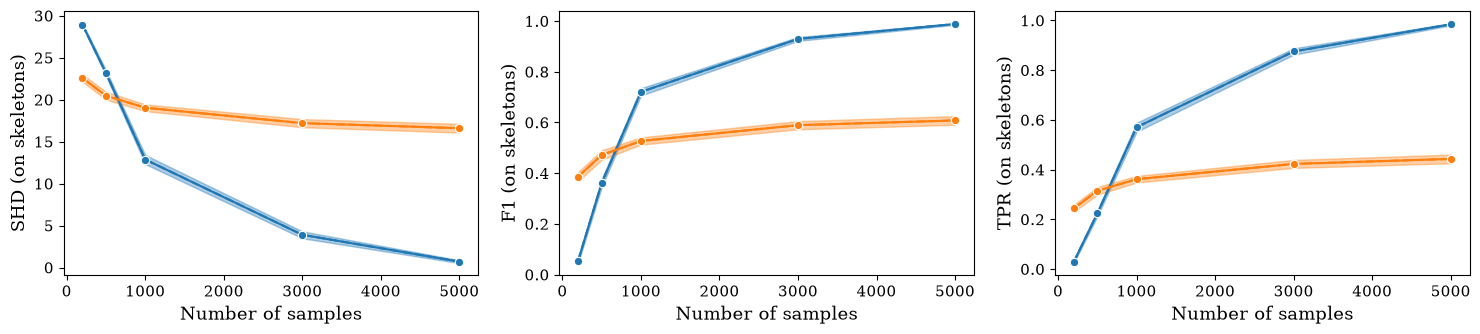

In [9]:
plot_generator("cbn_unif_mixture")